In [1]:
import  sklearn
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import warnings
from sklearn import preprocessing
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import shap
import copy
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import time
import lightgbm as lgb
from sklearn.model_selection import KFold

from sklearn.ensemble import RandomForestRegressor

import copy
import numpy as np
from xgboost import DMatrix, train
from sklearn.datasets import make_regression
from flaml import AutoML
np.random.seed(42)
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib
import pickle
import glob,os
import numpy as np
from scipy.stats import *
import xgboost as xgb
import numpy as np
from scipy.stats import mode
import copy
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings
# import pickle
# import mgwr
import pandas as pd
import gc
from sklearn.model_selection import train_test_split
import random
from sklearn.feature_selection import mutual_info_regression

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Microsoft YaHei'

# import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.utils import shuffle

<Figure size 1000x600 with 0 Axes>

In [ ]:
usingFeatures = [
    "IDW", "Lon", "Lat","LandCover", 
      "ForestCoverage", "ForestHeight", "ForestHeight10", "ForestHeight30",  "BuildingHeight90", "Population", "NightLight",  "Aspect",
      "Hillshade", "Curvature", "ProfileCurvature", "PlanCurvature",  "DEM", "STDDEM", "Max_MinDEM", "Mean_MinDEM", "deltMeanDEM", "deltMedianDEM", "deltMinDEM", "deltMaxDEM",
    "Slope", "MaxSlope", "STDSlope", "Mean_MinSlope", "Max_MinSlope", "deltMeanSlope", "SOS", "SOA","HEL","FCLoss","FCGain","NIR","RGB","SAR_VV","SAR_VH"
]


selected_features = [
      "ForestCoverage", "ForestHeight", "ForestHeight10", "ForestHeight30",  "BuildingHeight90", "Population", "NightLight",  "Aspect",
      "Hillshade", "Curvature", "ProfileCurvature", "PlanCurvature",  "DEM", "STDDEM", "Max_MinDEM", "Mean_MinDEM", "deltMeanDEM", "deltMedianDEM", "deltMinDEM", "deltMaxDEM",
    "Slope", "MaxSlope", "STDSlope", "Mean_MinSlope", "Max_MinSlope", "deltMeanSlope", "SOS", "SOA","HEL","FCLoss","FCGain","NIR","RGB","SAR_VV","SAR_VH"
]


In [ ]:

def load_tabular_from_npz(data, label):

  
    B, C, H, W = data.shape
    data_reshaped = data.transpose(0, 2, 3, 1).reshape(-1, C)  # (B*H*W, C)
    label_reshaped = label.reshape(-1)  # (B*H*W,)
    X, y = shuffle(data_reshaped, label_reshaped, random_state=42)

    return X, y




In [ ]:
# Dataset Available 
path=r"DataModels/test_data.npz"
test_data =np.load(path)['arr1']
test_labels =np.load(path)['arr2']
test_data_2d, test_labels_1d=load_tabular_from_npz(data=test_data,label=test_labels)

path=r"DataModels/train_data.npz"
train_data =np.load(path)['arr1']
train_labels =np.load(path)['arr2']
train_data_2d, train_labels_1d=load_tabular_from_npz(data=train_data,label=train_labels)

# AutoML - 300

In [ ]:

settings = {      
    "metric": "mse",              
    "estimator_list":'auto',      
    "task": "regression",          
    "eval_method": "cv",           
    "n_splits": 5,                  
    "early_stop": True,         
    "log_file_name": "flaml_log.txt",
    "verbose": 0,
    "seed": 42
}


automl = AutoML()
automl.fit(X_train=train_data_2d, y_train=train_labels_1d,** settings)
y_pred = automl.predict(test_data_2d)
current_rmse = round(np.sqrt(mean_squared_error(test_labels_1d, y_pred)),2)
print(f"Initial RMSE: {current_rmse:.4f}")

In [5]:

saveModel=r"DataModels/SHAP/Flaml_Model_005_Zsore180m.pkl"

with open(saveModel, "rb") as f:
    automl = pickle.load(f)

y_pred = automl.predict(test_data_2d)
current_rmse = round(np.sqrt(mean_squared_error(test_labels_1d, y_pred)),2)
print(f"RMSE: {current_rmse:.4f}")

RMSE: 4.0300


## SHAP 

In [6]:
best_model = automl.model.model
explainer = shap.TreeExplainer(best_model)


shap_values = explainer.shap_values(test_data_2d)

test_data_df = pd.DataFrame(test_data_2d, columns=selected_features)

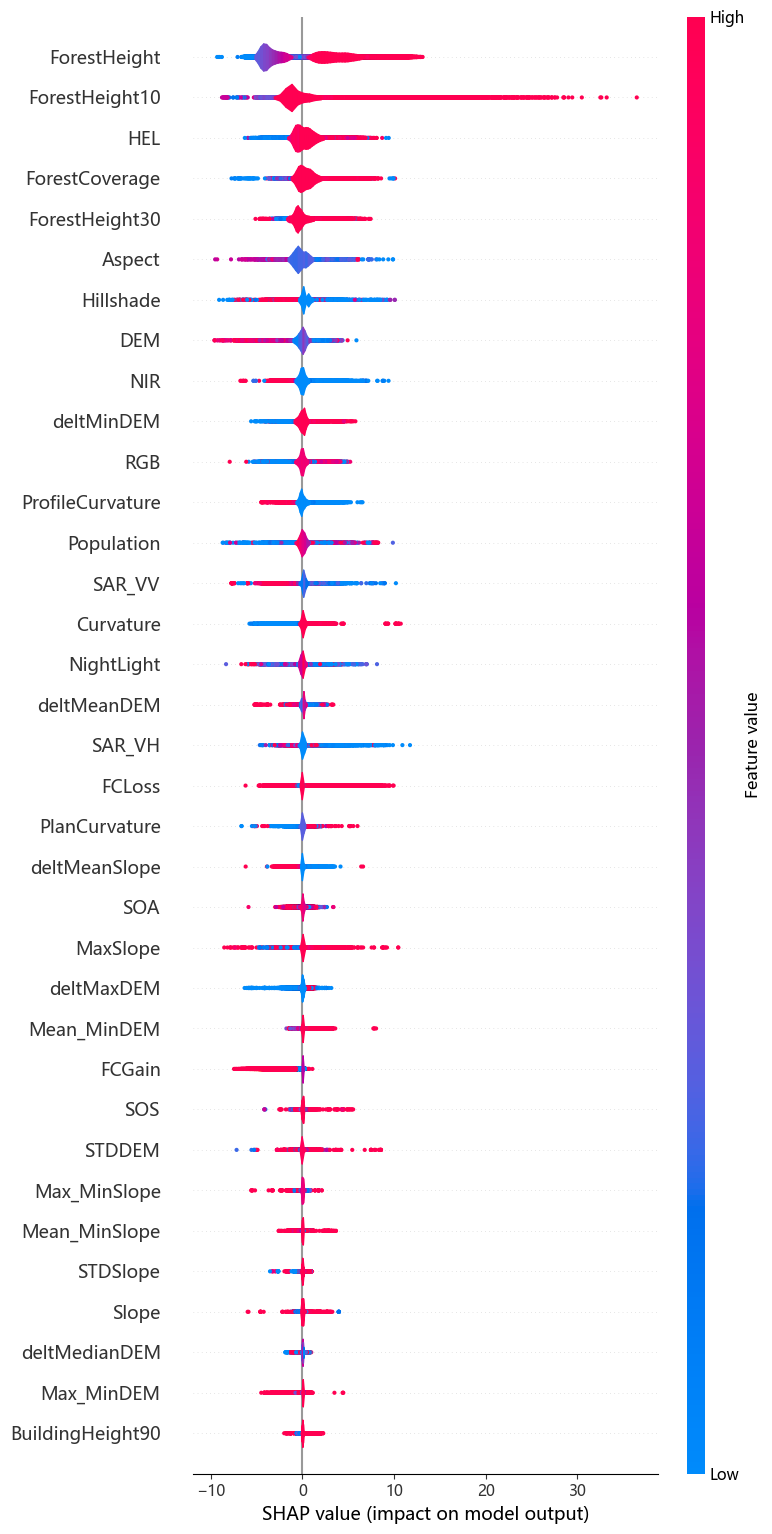

In [7]:
shap.summary_plot(shap_values, test_data_df, plot_type="violin", max_display=len(test_data_df.columns))

In [ ]:

shap_abs_mean = np.abs(shap_values).mean(axis=0)


feature_importance = dict(zip(test_data_df.columns, shap_abs_mean))


sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)


sorted_feature_names = [feature[0] for feature in sorted_features]

print(sorted_feature_names)


['ForestHeight', 'ForestHeight10', 'HEL', 'ForestCoverage', 'ForestHeight30', 'Aspect', 'Hillshade', 'DEM', 'NIR', 'deltMinDEM', 'RGB', 'ProfileCur', 'Pop', 'SAR_VV', 'Curvature', 'NightLight', 'deltMeanDEM', 'SAR_VH', 'FCLoss', 'PlanCur', 'deltMeanSlope', 'SOA', 'MaxSlope', 'deltMaxDEM', 'Mean_MinDEM', 'FCGain', 'SOS', 'STDDEM', 'Max_MinSlope', 'Mean_MinSlope', 'STDSlope', 'Slope', 'deltMedianDEM', 'Max_MinDEM', 'BuildingHeight90']


In [ ]:
removeClustered=['HEL','ForestCoverage', 'Aspect', 'Hillshade',  'NIR', 'deltMinDEM', 'RGB', 'ProfileCur', 'Pop', 'SAR_VV', 'Curvature', 'NightLight',  'FCLoss', 'deltMeanSlope', 'SOA', 'deltMaxDEM',  'FCGain', 'SOS' ]

SHAPTop15=['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'HEL', 'ForestCoverage', 'ForestHeight30', 'Aspect', 'Hillshade', 'DEM', 'NIR', 'deltMinDEM', 'RGB',   'ProfileCur', 'Pop', 'SAR_VV']

CNNSHAP15=['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB',    'SAR_VV', 'Curvature', 'FCLoss']

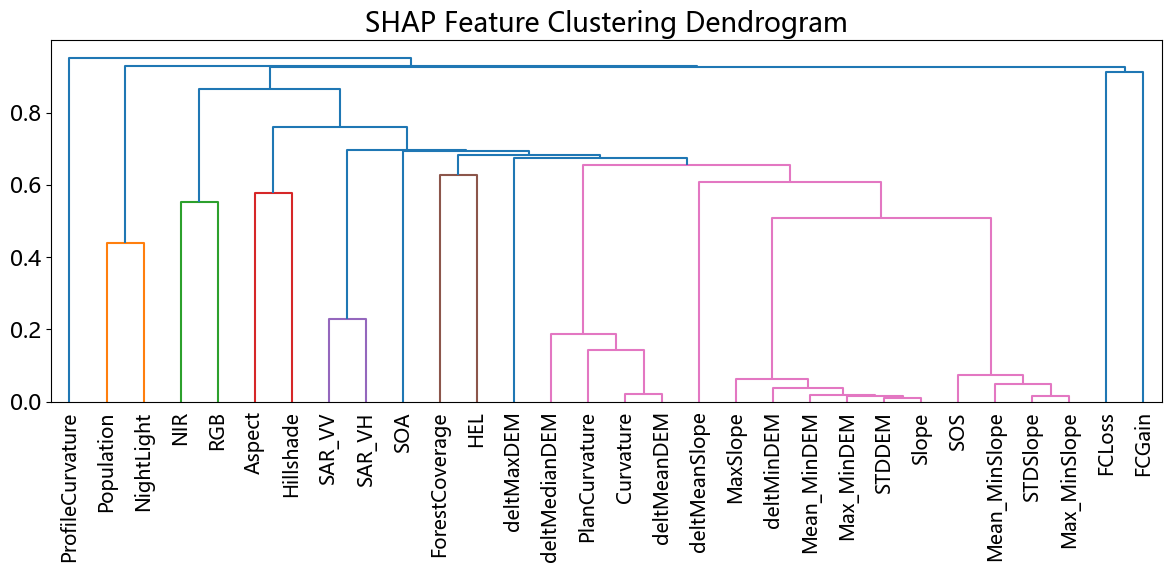

In [ ]:
import shap
import pandas as pd
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 16



noInitial_features=[
    "ForestCoverage", "Population", "NightLight",
    "Aspect", "Hillshade", "Curvature", "ProfileCurvature", "PlanCurvature", 
    "STDDEM", "Max_MinDEM", "Mean_MinDEM", "deltMeanDEM", "deltMedianDEM", "deltMinDEM", "deltMaxDEM",
    "Slope", "MaxSlope", "STDSlope", "Mean_MinSlope", "Max_MinSlope", "deltMeanSlope", "SOS", "SOA","HEL","FCLoss","FCGain","NIR","RGB","SAR_VV","SAR_VH"
]

test_data_df = pd.DataFrame(test_data_2d, columns=selected_features)


clustering = shap.utils.hclust(test_data_df[noInitial_features])


plt.figure(figsize=(12, 6))
dendrogram(clustering, labels=noInitial_features, leaf_font_size=14)
plt.title("SHAP Feature Clustering Dendrogram")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Section 5.3

In [ ]:
shap_df=pd.DataFrame(shap_values, columns=selected_features)
shap_df

In [74]:

test_df_BH=test_data_df[["ForestCoverage", "ForestHeight10", "BuildingHeight90","Population","NightLight" ]]
test_df_BH["shap_FC"]=shap_df["ForestCoverage"]
test_df_BH["shap_FH10"]=shap_df["ForestHeight10"]
test_df_BH["shap_BH"]=shap_df["BuildingHeight90"]
test_df_BH["shap_Pop"]=shap_df["Population"]
test_df_BH["shap_Night"]=shap_df["NightLight"]
test_df_BH

,ForestCoverage,ForestHeight10,BuildingHeight90,Population,NightLight,shap_FC,shap_FH10,shap_BH,shap_Pop,shap_Night
0,-1.353065,-1.585156,-0.109048,-0.081551,0.122292,-0.685541,-1.353072,-0.001718,-0.030633,-0.011374
1,-1.590775,-1.585156,-0.109048,-0.108742,-0.103979,0.884807,-1.672602,-0.003453,0.214713,-0.100645
2,0.735821,-0.964563,-0.109048,-0.124772,-0.263380,0.660648,-1.926205,-0.001049,-0.052773,-0.209785
3,1.024029,0.173190,-0.109048,-0.114110,-0.055834,0.884781,-1.565315,0.004958,0.014482,-0.255902
4,-0.050795,-0.033675,-0.109048,-0.121847,-0.112863,0.162588,-0.161179,0.000305,-0.174726,-0.031323
...,...,...,...,...,...,...,...,...,...,...
2830331,1.063647,0.069757,-0.109048,-0.113675,-0.054436,1.323501,-1.783624,0.000810,-0.212100,-0.213985
2830332,1.100773,-0.343971,-0.109048,-0.114768,-0.234715,1.092905,-1.266275,-0.003352,0.055098,0.045167
2830333,-1.551156,-0.447403,5.746748,1.236824,-0.001924,-0.350468,-0.964701,-0.001530,0.514447,0.227718
2830334,0.710170,0.897214,-0.109048,-0.124448,-0.083574,1.185105,0.689137,0.001294,-0.213778,-0.200557


In [86]:
65266/2830336 

0.023059453011939218

In [ ]:
mean_std_path=r"DataModels/mean_std.npz"

mean_val_all = np.load(mean_std_path)['mean']
std_val_all = np.load(mean_std_path)['std']

mean = mean_val_all[0, usingFeatures.index('BuildingHeight90') , 0, 0] 
std = std_val_all[0, usingFeatures.index('BuildingHeight90') , 0, 0]    

test_df_BH['BH_org'] = (test_df_BH['BuildingHeight90'] * std) + mean
test_df_BH

,ForestCoverage,ForestHeight10,BuildingHeight90,Population,NightLight,shap_FC,shap_FH10,shap_BH,shap_Pop,shap_Night,BH_org
0,-1.353065,-1.585156,-0.109048,-0.081551,0.122292,-0.685541,-1.353072,-0.001718,-0.030633,-0.011374,0.0
1,-1.590775,-1.585156,-0.109048,-0.108742,-0.103979,0.884807,-1.672602,-0.003453,0.214713,-0.100645,0.0
2,0.735821,-0.964563,-0.109048,-0.124772,-0.263380,0.660648,-1.926205,-0.001049,-0.052773,-0.209785,0.0
3,1.024029,0.173190,-0.109048,-0.114110,-0.055834,0.884781,-1.565315,0.004958,0.014482,-0.255902,0.0
4,-0.050795,-0.033675,-0.109048,-0.121847,-0.112863,0.162588,-0.161179,0.000305,-0.174726,-0.031323,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2830331,1.063647,0.069757,-0.109048,-0.113675,-0.054436,1.323501,-1.783624,0.000810,-0.212100,-0.213985,0.0
2830332,1.100773,-0.343971,-0.109048,-0.114768,-0.234715,1.092905,-1.266275,-0.003352,0.055098,0.045167,0.0
2830333,-1.551156,-0.447403,5.746748,1.236824,-0.001924,-0.350468,-0.964701,-0.001530,0.514447,0.227718,3.3
2830334,0.710170,0.897214,-0.109048,-0.124448,-0.083574,1.185105,0.689137,0.001294,-0.213778,-0.200557,0.0


In [78]:
BH0=test_df_BH[(test_df_BH['BH_org'] == 0)]
BH0

,ForestCoverage,ForestHeight10,BuildingHeight90,Population,NightLight,shap_FC,shap_FH10,shap_BH,shap_Pop,shap_Night,BH_org
0,-1.353065,-1.585156,-0.109048,-0.081551,0.122292,-0.685541,-1.353072,-0.001718,-0.030633,-0.011374,0.0
1,-1.590775,-1.585156,-0.109048,-0.108742,-0.103979,0.884807,-1.672602,-0.003453,0.214713,-0.100645,0.0
2,0.735821,-0.964563,-0.109048,-0.124772,-0.263380,0.660648,-1.926205,-0.001049,-0.052773,-0.209785,0.0
3,1.024029,0.173190,-0.109048,-0.114110,-0.055834,0.884781,-1.565315,0.004958,0.014482,-0.255902,0.0
4,-0.050795,-0.033675,-0.109048,-0.121847,-0.112863,0.162588,-0.161179,0.000305,-0.174726,-0.031323,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2830330,-1.042864,-0.757699,-0.109048,-0.124355,-0.151514,-0.183635,-1.824594,-0.002703,-0.339135,-0.240454,0.0
2830331,1.063647,0.069757,-0.109048,-0.113675,-0.054436,1.323501,-1.783624,0.000810,-0.212100,-0.213985,0.0
2830332,1.100773,-0.343971,-0.109048,-0.114768,-0.234715,1.092905,-1.266275,-0.003352,0.055098,0.045167,0.0
2830334,0.710170,0.897214,-0.109048,-0.124448,-0.083574,1.185105,0.689137,0.001294,-0.213778,-0.200557,0.0


In [79]:
BHL0=test_df_BH[(test_df_BH['BH_org'] > 0)]
BHL0

,ForestCoverage,ForestHeight10,BuildingHeight90,Population,NightLight,shap_FC,shap_FH10,shap_BH,shap_Pop,shap_Night,BH_org
83,-0.956883,-0.550835,4.682058,0.862934,1.271957,-0.237934,-1.508207,-0.015925,0.181282,-0.106243,2.7
118,-0.956883,-0.240539,8.053576,2.936417,1.432400,-0.825579,-1.279350,0.256152,0.032386,-0.296172,4.6
187,-1.418808,-2.102316,0.245849,-0.124885,-0.205409,-0.587837,-1.787030,-0.102697,0.008817,0.107006,0.2
248,-1.630393,-1.067995,7.343783,25.760438,12.582485,0.909224,-1.737261,0.577791,0.357199,-0.517159,4.2
282,-1.551156,-1.171428,6.988886,0.687725,0.859884,0.138557,-0.929406,0.457082,0.259040,0.352655,4.0
...,...,...,...,...,...,...,...,...,...,...,...
2830129,0.865556,2.345263,0.245849,0.084536,0.260807,0.543420,4.328284,-0.352884,1.132892,-1.908568,0.2
2830183,-1.471920,-0.964563,11.957440,0.132626,0.066440,0.335240,-1.774526,0.650663,0.468519,-0.171083,6.8
2830191,-0.481464,1.000646,0.245849,0.437556,0.204553,-0.606343,1.172883,-0.103970,0.930419,-0.238095,0.2
2830308,-0.085282,0.483486,0.423297,-0.012436,0.083083,-1.130853,-1.106761,-0.258148,0.144377,-0.382032,0.3


In [ ]:
import copy
df=copy.deepcopy(test_df_BH)


bins = [-1, 0.0001, 2, 5, 10, 20, 30, 40, 50] 
labels = ['0','0-2', '2-5','5-10', '10-20','20-30','30-','40-50'] 

df['BH_org_range'] = pd.cut(df['BH_org'], bins=bins, labels=labels, right=True)


result = df.groupby('BH_org_range')['shap_BH'].mean().reset_index()


print(result)

  BH_org_range   shap_BH
0            0 -0.001433
1          0-2 -0.159037
2          2-5  0.089477
3         5-10  0.362112
4        10-20  0.968157
5        20-30  1.013446
6          30-  1.147506
7        40-50       NaN


Text(0, 0.5, 'SHAP value')

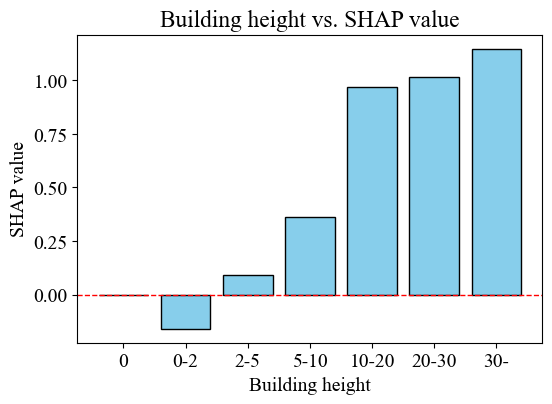

In [ ]:
plt.figure(figsize=(6, 4))
plt.axhline(y=0, color='red', linewidth=1, linestyle='--')  
plt.bar(result['BH_org_range'], result['shap_BH'], color='skyblue', edgecolor='black')


plt.title('Building height vs. SHAP value')
plt.xlabel('Building height')
plt.ylabel('SHAP value')

# Setion 5.1

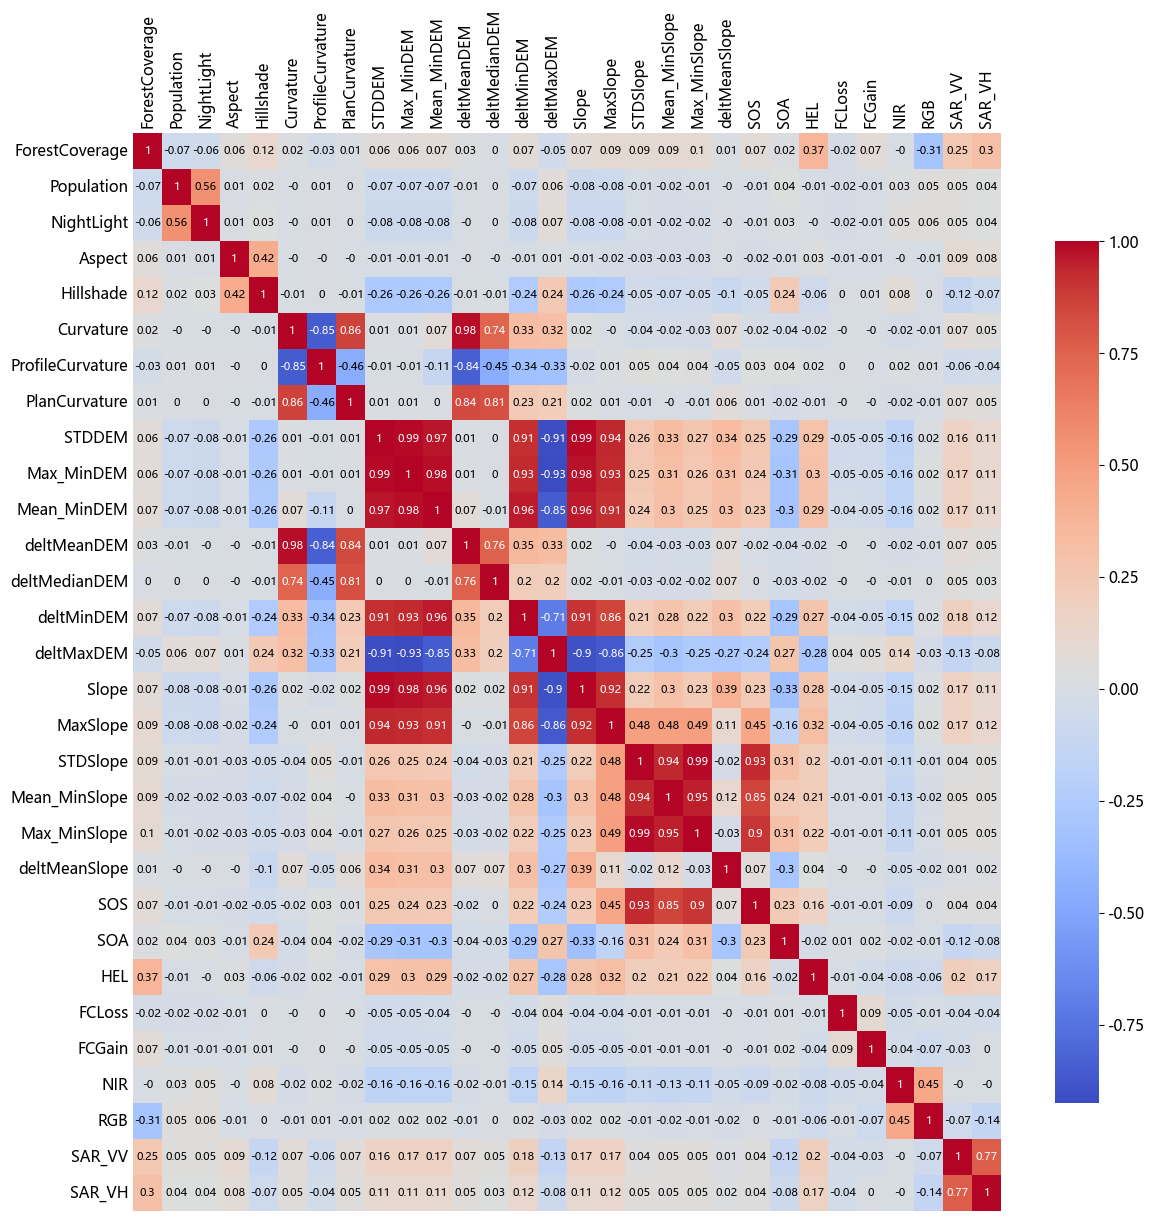

In [ ]:
import seaborn as sns
import warnings
import pickle

df_cor = pd.DataFrame(test_data_2d, columns=selected_features)


correlation_matrix = df_cor.corr()

plt.figure(figsize=(14, 14))

plt.rcParams['font.size'] = 11  
plt.rcParams['axes.unicode_minus'] = False 


def custom_fmt(x):
    if x == 1 or x == -1:  
        return f"{int(x)}"
    return f"{x:.2f}".rstrip('0').rstrip('.')  


ax = sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt="", 
    annot_kws={"size": 8}, 
    cbar_kws={"shrink": 0.8}
)


for text in ax.texts:
    value = float(text.get_text())  
    text.set_text(custom_fmt(value)) 

    if abs(value) >= 0.7:
        text.set_color("white")  
    else:
        text.set_color("black")  


ax.xaxis.tick_top()
ax.tick_params(axis='both', which='both', length=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center') 
ax.xaxis.set_label_position('top')

plt.show()


In [ ]:

from collections import defaultdict
correlation_matrix = correlation_matrix.abs() 
threshold = 0.7


graph = defaultdict(set)
for i in correlation_matrix.columns:
    for j in correlation_matrix.columns:
        if i != j and correlation_matrix.loc[i, j] >= threshold:
            graph[i].add(j)
            graph[j].add(i)


visited = set()
groups = []

def dfs(node, group):
    for neighbor in graph[node]:
        if neighbor not in visited:
            visited.add(neighbor)
            group.append(neighbor)
            dfs(neighbor, group)

for node in correlation_matrix.columns:
    if node not in visited:
        group = [node]
        visited.add(node)
        dfs(node, group)
        groups.append(sorted(group))


all_grouped_vars = set([v for group in groups for v in group])
all_vars = set(correlation_matrix.columns)
for var in all_vars - all_grouped_vars:
    groups.append([var])


print("变量分组结果：")
for idx, g in enumerate(groups, 1):
    print(f"Group {idx}: {g}")

变量分组结果：
Group 1: ['ForestCoverage', 'ForestHeight', 'ForestHeight10', 'ForestHeight30']
Group 2: ['BuildingHeight90']
Group 3: ['Pop']
Group 4: ['NightLight']
Group 5: ['Aspect']
Group 6: ['Hillshade']
Group 7: ['Curvature', 'PlanCur', 'ProfileCur', 'deltMeanDEM', 'deltMedianDEM']
Group 8: ['DEM']
Group 9: ['MaxSlope', 'Max_MinDEM', 'Mean_MinDEM', 'STDDEM', 'Slope', 'deltMaxDEM', 'deltMinDEM']
Group 10: ['Max_MinSlope', 'Mean_MinSlope', 'SOS', 'STDSlope']
Group 11: ['deltMeanSlope']
Group 12: ['SOA']
Group 13: ['HEL']
Group 14: ['FCLoss']
Group 15: ['FCGain']
Group 16: ['NIR']
Group 17: ['RGB']
Group 18: ['SAR_VH', 'SAR_VV']


# ML   Gini

In [ ]:
saveModel=r"DataModels/SHAP/Flaml_Model_005_Zsore180m.pkl"
with open(saveModel, "rb") as f:
    automl = pickle.load(f)

y_pred = automl.predict(test_data_2d)
mse = mean_squared_error(test_labels_1d, y_pred)
rmse = np.sqrt(mse)
print(f"Validation RMSE: {rmse:.4f}") 

importance = automl.model.feature_importances_
feature_names = selected_features  
sorted_idx = np.argsort(importance)[::-1]
print("=== Feature Importance Ranking ===")
for idx in sorted_idx:
    print(f"{feature_names[idx]:25s}  {importance[idx]:.6f}")

Validation RMSE: 4.0276
=== Feature Importance Ranking ===
DEM                        564.000000
Pop                        482.000000
ForestHeight10             476.000000
NightLight                 461.000000
ForestHeight               395.000000
ForestCoverage             390.000000
HEL                        356.000000
RGB                        323.000000
Aspect                     303.000000
ForestHeight30             241.000000
NIR                        191.000000
SAR_VH                     190.000000
SAR_VV                     177.000000
MaxSlope                   175.000000
Hillshade                  175.000000
deltMinDEM                 97.000000
ProfileCur                 96.000000
FCLoss                     85.000000
SOA                        75.000000
deltMaxDEM                 61.000000
deltMeanDEM                60.000000
deltMeanSlope              59.000000
PlanCur                    57.000000
Curvature                  55.000000
Mean_MinDEM                32.000000
S

# MInformation

In [ ]:
mi_scores = mutual_info_regression(test_data_2d, test_labels_1d, random_state=42)


mi_df = pd.DataFrame({
    'Feature': selected_features,
    'MI': mi_scores
})


mi_df_sorted = mi_df.sort_values(by='MI', ascending=False)
mi_df_sorted

,Feature,MI
1,ForestHeight,0.581795
2,ForestHeight10,0.515175
3,ForestHeight30,0.511253
0,ForestCoverage,0.454164
28,HEL,0.279861
32,RGB,0.267662
34,SAR_VH,0.213171
33,SAR_VV,0.149699
21,MaxSlope,0.064192
12,DEM,0.060804


In [ ]:
selected_features=['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'DEM',   'ForestCoverage','HEL', 'RGB',  'SAR_VH', 'MaxSlope',"Pop"]




# Permulation

In [ ]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
from sklearn.metrics import make_scorer, mean_squared_error
"""
n_repeats 的作用就是：🔹 重复打乱同一个特征多次，然后取平均和标准差，避免单次打乱带来的偶然性。

"""


rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

def ann_perm_importance(model, X, y, feature_names, n_repeats=10, random_state=42):
    r = permutation_importance(
        model, X, y,
        scoring=rmse_scorer,  
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )
    imp = pd.DataFrame({
        "feature": feature_names,
        "perm_mean": r.importances_mean,  
        "perm_std":  r.importances_std
    })
    imp["rank"] = imp["perm_mean"].rank(ascending=False, method="dense").astype(int)
    imp=imp.sort_values(by="rank", ascending=True).reset_index(drop=True)
    return imp



saveModel=r"DataModels/SHAP/Flaml_Model_0106_Zsore180m.pkl"
with open(saveModel, "rb") as f:
    best_model = pickle.load(f)

perm = ann_perm_importance(best_model, test_data_2d, test_labels_1d, feature_names=selected_features,n_repeats=10)
perm


# Draws

In [12]:
SHAP_list = ["ForestHeight", "ForestHeight10", "HEL", "ForestCoverage", "ForestHeight30", "Aspect", 
                 "Hillshade", "DEM", "NIR", "deltMinDEM", "RGB", "ProfileCur", "Population", "SAR_VV", 
                 "Curvature", "NightLight", "deltMeanDEM", "SAR_VH", "FCLoss", "PlanCur", "deltMeanSlope", 
                 "SOA", "MaxSlope", "deltMaxDEM", "Mean_MinDEM", "FCGain", "SOS", "STDDEM", "Max_MinSlope", 
                 "Mean_MinSlope", "STDSlope", "Slope", "deltMedianDEM", "Max_MinDEM", "BuildingHeight90"]

MI_list = [
    "ForestHeight", "ForestHeight10", "ForestHeight30", "ForestCoverage", "HEL", "RGB", 
    "SAR_VH", "SAR_VV", "MaxSlope", "DEM", "Mean_MinDEM", "Max_MinDEM", "STDDEM", "deltMinDEM", 
    "Population", "Slope", "Max_MinSlope", "Mean_MinSlope", "deltMaxDEM", "STDSlope", "Hillshade", 
    "ProfileCur", "Curvature", "deltMeanDEM", "NightLight", "PlanCur", "Aspect", "NIR", 
    "deltMeanSlope", "deltMedianDEM", "SOS", "BuildingHeight90", "FCGain", "SOA", "FCLoss"
]

Gini_list = [
    "DEM", "Pop", "ForestHeight10", "NightLight", "ForestHeight", "ForestCoverage", 
    "HEL", "RGB", "Aspect", "ForestHeight30", "NIR", "SAR_VH", "SAR_VV", "MaxSlope", 
    "Hillshade", "deltMinDEM", "ProfileCur", "FCLoss", "SOA", "deltMaxDEM", "deltMeanDEM", 
    "deltMeanSlope", "PlanCur", "Curvature", "Mean_MinDEM", "Slope", "FCGain", "SOS", 
    "Mean_MinSlope", "STDSlope", "Max_MinSlope", "STDDEM", "deltMedianDEM", "Max_MinDEM", 
    "BuildingHeight90"
]

PerML_list = [
    "ForestHeight", "Aspect", "Hillshade", "ForestHeight10", "ForestCoverage", "HEL", 
    "ForestHeight30", "DEM", "RGB", "NIR", "Population", "SAR_VH", "SAR_VV", "deltMinDEM", 
    "NightLight", "FCLoss", "ProfileCur", "Curvature", "deltMeanDEM", "SOA", "PlanCur", 
    "FCGain", "Mean_MinDEM", "deltMeanSlope", "MaxSlope", "deltMaxDEM", "STDDEM", "Slope", 
    "SOS", "deltMedianDEM", "STDSlope", "Mean_MinSlope", "BuildingHeight90", "Max_MinSlope", 
    "Max_MinDEM"
]

PerCNN_list = [
    'ForestHeight', 'HEL', 'ForestHeight30', 'deltMeanDEM', 'ProfileCur',
    'ForestHeight10', 'ForestCoverage', 'NIR', 'Curvature', 'FCLoss',
    'FCGain', 'SAR_VV', 'DEM', 'PlanCur', 'Aspect', 'STDDEM', 'Hillshade',
    'SAR_VH', 'deltMaxDEM', 'deltMinDEM', 'deltMeanSlope', 'Max_MinDEM',
    'Mean_MinDEM', 'Slope', 'deltMedianDEM', 'SOA', 'RGB', 'NightLight',
    'STDSlope', 'Mean_MinSlope', 'SOS', 'MaxSlope', 'Population', 'BuildingHeight90',
    'Max_MinSlope'
]


# Filter the features to ensure they are present in all lists
common_features = [feature for feature in SHAP_list if feature in Gini_list and feature in MI_list and feature in PerML_list]

# Create a DataFrame using only the common features
df_common = pd.DataFrame(index=common_features)

# Assign ranks based on the feature positions in each list
df_common['SHAP'] = [SHAP_list.index(f) + 1 for f in df_common.index]
df_common['Gini'] = [Gini_list.index(f) + 1 for f in df_common.index]
df_common['MI'] = [MI_list.index(f) + 1 for f in df_common.index]
df_common['CPML'] = [PerML_list.index(f) + 1 for f in df_common.index]
df_common['CPCNN'] = [PerCNN_list.index(f) + 1 for f in df_common.index]


# df_common

df = pd.DataFrame()
df["Proposed"]=SHAP_list
df["SHAP"]=SHAP_list
df["Gini"]=Gini_list
df["MI"]=MI_list
df["CPML"]=PerML_list
df["CPCNN"]=PerCNN_list
df


,Proposed,SHAP,Gini,MI,CPML,CPCNN
0,ForestHeight,ForestHeight,DEM,ForestHeight,ForestHeight,ForestHeight
1,ForestHeight10,ForestHeight10,Pop,ForestHeight10,Aspect,HEL
2,HEL,HEL,ForestHeight10,ForestHeight30,Hillshade,ForestHeight30
3,ForestCoverage,ForestCoverage,NightLight,ForestCoverage,ForestHeight10,deltMeanDEM
4,ForestHeight30,ForestHeight30,ForestHeight,HEL,ForestCoverage,ProfileCur
5,Aspect,Aspect,ForestCoverage,RGB,HEL,ForestHeight10
6,Hillshade,Hillshade,HEL,SAR_VH,ForestHeight30,ForestCoverage
7,DEM,DEM,RGB,SAR_VV,DEM,NIR
8,NIR,NIR,Aspect,MaxSlope,RGB,Curvature
9,deltMinDEM,deltMinDEM,ForestHeight30,DEM,NIR,FCLoss
